# 🔄 Backtesting Engine - Portfolio Construction & Performance Calculation

## Overview
This notebook implements a 10-90 decile portfolio backtesting engine that constructs Long-Short portfolios from trading signals. It applies Fama-French methodology: NYSE P20 market cap filtering, 10th/90th percentile breakpoints, and monthly rebalancing. The engine processes multiple signals in batch mode and outputs portfolio returns for downstream analysis.



## 🎯 Generated Outputs

**Output Folder**: `data/`

### 📊 Main Portfolio Returns
* **Files**: `data/portfolios/{signal_name}_signal.parquet`
* **Examples**:
    * `investment_capex_signal.parquet`
    * `change_current_ratio_signal.parquet`
    * `debt_capacity_signal.parquet`
* **Columns**:
    * `date`: Month-end date
    * `year_formed`: Formation year (June year $t$)
    * `ret_ls_vw`: Long-Short return (Value-Weighted) = $ret_{high,vw} - ret_{low,vw}$
    * `ret_low_vw`: LOW portfolio VW return (Bottom 10% signal)
    * `ret_high_vw`: HIGH portfolio VW return (Top 10% signal)
    * `ret_ls_ew`: Long-Short return (Equal-Weighted)
    * `ret_low_ew`: LOW portfolio EW return
    * `ret_high_ew`: HIGH portfolio EW return
    * `turnover_low`: Monthly turnover in LOW portfolio (VW)
    * `turnover_high`: Monthly turnover in HIGH portfolio (VW)
    * `turnover_low_ew`: Monthly turnover in LOW portfolio (EW)
    * `turnover_high_ew`: Monthly turnover in HIGH portfolio (EW)
    * `holdings_low_vw`: Number of stocks in LOW portfolio
    * `holdings_high_vw`: Number of stocks in HIGH portfolio
* **Period**: 1963-2024 (monthly observations)

### 📈 Double-Sort Results (Size × Signal)
* **Files**: `data/portfolios/doublesorting/{signal_name}_10_90.parquet`
* **Example**: `investment_capex_10_90.parquet`
* **Structure**:
    * **Columns**: `date`, `ret_vw`, `ret_ew`, `size_bin`, `signal_bin`
    * **Dimensions**: 2 size bins (Large/Small NYSE) × 10 signal deciles = 20 portfolios
    * **Weighting**: Both VW and EW returns calculated
    * **Period**: Monthly (1963-2024)



### 🔢 Breakpoint Cache Files
* **Files**: `data/breakpoints/{signal_name}_breakpoints.parquet`
* **Example**: `investment_capex_breakpoints.parquet`
* **Columns**:
    * `year`: Formation year
    * `p10`: 10th percentile breakpoint (Low portfolio threshold)
    * `p90`: 90th percentile breakpoint (High portfolio threshold)
* **Purpose**: Cache annual signal thresholds to avoid recomputation



## 📂 Input Data Files

### 1. Stock Returns
* **File**: `raw_data_processing/data/d_dataset_full/data.parquet`
* **Structure**:
    * `PERMNO`: Stock identifier (CRSP)
    * `date`: Month-end date
    * `ret_adj`: Adjusted monthly return (decimal)
* **Preprocessing**:
    * Deduplicated by `(PERMNO, mthdate)`
    * Renamed `ret_adj` → `ret`
* **Period**: 1963-2024

### 2. Market Capitalization Data
* **File**: `raw_data_processing/data/b_processed/crsp_with_delistings.parquet`
* **Structure**:
    * `PERMNO`: Stock identifier
    * `date`: Month-end date
    * `PRC`: Stock price
    * `SHROUT`: Shares outstanding (in thousands)
    * `EXCHCD`: Exchange code (1 = NYSE, 2 = AMEX, 3 = NASDAQ)
* **Calculation**:
    ```python
    market_cap = abs(PRC) * SHROUT / 1000  # Result in $M
    ```
* **Preprocessing**:
    * Deduplicated by `(PERMNO, mthdate)`
    * Filtered by `EXCHCD = 1` (NYSE only for breakpoint calculation)

### 3. Trading Signals
* **File**: `data/signals/signals_ALL.parquet`
* **Structure**:
    * `PERMNO`: Stock identifier
    * `fyear`: Fiscal year
    * `mthdate`: Month date
    * `portfolio_date`: Portfolio formation date (June only)
    * **Signal columns** (auto-detected): `investment_capex`, `change_current_ratio`, `debt_capacity`, `noa_change`, etc.
* **Filtering**:
    * Keep only rows where `portfolio_date IS NOT NULL` (June formations)
    * Drop metadata columns: `PERMNO`, `fyear`, `portfolio_date`, `mthdate` from signal list
* **Source**: Output from previous signal construction pipeline

---

## 🔬 Methodology

### Configuration (Cell 3)
```python
CONFIG = {
    'mode': 'auto',  # 'manual' for single signal, 'auto' for batch processing
    'portfolio_thresholds': [0.10, 0.90],  # 10th and 90th percentiles
    'date_range': ('1963-01-01', '2024-12-31'),
    'min_firms': 10,  # Minimum stocks per portfolio
    'min_history': 24  # Minimum 24-month history required
}

````

### Portfolio Construction Logic

#### Step 1: NYSE P20 Market Cap Filter (Cell 6-8)
* **Purpose**: Exclude micro-cap stocks (Fama-French standard)
* **Calculation**:
    * For each **June** (year $t$):
        1.  Filter stocks: `EXCHCD = 1` (NYSE only)
        2.  Compute 20th percentile of market cap (`P20_threshold`)
        3.  Apply filter to **all stocks** (NYSE + AMEX + NASDAQ): Keep only stocks with `market_cap ≥ P20_threshold`
* **Diagnostic Output**:
    * Figure: 2-panel plot showing P20 evolution (1963-2024) and growth rate histogram

#### Step 2: Signal Breakpoints Calculation (Cell 10)
* **Function**: `compute_signal_breakpoints(signal_name)`
* **Process**:
    * For each **June** (year $t$):
        1.  Filter stocks: `EXCHCD = 1` AND `market_cap ≥ NYSE_P20`
        2.  Compute **10th percentile** (`p10`) and **90th percentile** (`p90`) of signal values
        3.  Save to: `data/breakpoints/{signal_name}_breakpoints.parquet`
* **Cache Behavior**: Load from disk if exists, else compute fresh

#### Step 3: Portfolio Assignment (Cell 12)
* **Function**: `build_signal_dict(signal_name, breakpoints_df)`
* **Filters Applied**:
    * NYSE P20 filter: `market_cap ≥ P20_threshold` (from May year $t$)
    * Minimum history: Require 24 prior monthly returns
    * Signal availability: Stock must have non-missing signal value
* **Portfolio Rules**:
    * **P_LOW**: Stocks with `signal_value ≤ p10` (Bottom 10%)
    * **P_HIGH**: Stocks with `signal_value ≥ p90` (Top 10%)
    * Excluded: Stocks in middle 80% (not traded)
* **Holding Period**:
    * **Formation**: June year $t$ (using May market caps)
    * **Holding**: July year $t$ → June year $t+1$ (12 months)
    * **Rebalancing**: Monthly weight adjustments within holding period
* **Output Structure**:
    ```python
    {
      1980: {
        'P_LOW': {
          'permnos': [12345, 67890, ...],
          'mktcap_formation': [100.5, 200.3, ...],  # May year t
          'signal_vals': [0.05, 0.08, ...],
          'mktcap_by_month': {
            '1980-07': pd.DataFrame([PERMNO, mktcap, ret]),
            '1980-08': pd.DataFrame([PERMNO, mktcap, ret]),
            ...
          }
        },
        'P_HIGH': { ... }
      },
      1981: { ... }
    }
    ```

#### Step 4: Value-Weighted Returns (Cell 14)
* **Function**: `compute_monthly_returns_vw(signal_dict)`
* **Weights Calculation**:
    ```python
    # Formation weights (May year t)
    weight_formation[PERMNO] = mktcap_May[PERMNO] / sum(mktcap_May)

    # Monthly weights (rebalanced each month during holding period)
    weight_monthly[PERMNO] = mktcap_current[PERMNO] / sum(mktcap_current)
    ```
* **Return Calculation**:
    ```python
    # Portfolio return for month m
    ret_portfolio_m = Σ(weight_monthly[PERMNO] × ret[PERMNO])

    # Long-Short return
    ret_ls_vw = ret_high_vw - ret_low_vw
    ```
* **Turnover Calculation**:
    * Inter-annual (June → June): $0.5 \times \Sigma |weight_{t+1} - weight_t|$
    * Intra-annual (monthly): $0.5 \times \Sigma |weight_{m+1} - weight_m|$
* **Output Columns**: `date`, `year_formed`, `ret_ls_vw`, `ret_low_vw`, `ret_high_vw`, `turnover_low`, `turnover_high`, `holdings_low_vw`, `holdings_high_vw`

#### Step 5: Equal-Weighted Returns (Cell 15)
* **Function**: `compute_monthly_returns_ew(signal_dict)`
* **Weights Calculation**:
    ```python
    # Each month during holding period
    N_available = count(stocks with valid return data)
    weight_EW[PERMNO] = 1.0 / N_available
    ```
* **Return Calculation**:
    ```python
    ret_portfolio_m = (1/N) × Σ ret[PERMNO]
    ret_ls_ew = ret_high_ew - ret_low_ew
    ```
* **Output Columns**: `ret_ls_ew`, `ret_low_ew`, `ret_high_ew`, `turnover_low_ew`, `turnover_high_ew`

#### Step 6: Merge and Export (Cell 16, 18)
* **Function**: `merge_vw_ew_returns()` → `run_backtest_for_signal()`
* **Process**:
    1. Merge VW and EW results on `date`
    2. Save to: `data/portfolios/{signal_name}_signal.parquet`
    3. Return merged DataFrame

#### Step 7: Double Sort (Cell 20)
* **Function**: `run_conditional_double_sort(signal_name)`
* **Methodology**:
    * **Size Bins**: 2 bins (Large/Small) using NYSE median market cap
    * **Signal Bins**: 10 deciles (using 10-90 thresholds + 8 intermediate bins)
    * **Weighting**: Both VW and EW calculated
    * **Lag**: 1-month lag for weights (standard academic practice)
* **Output**: 20 portfolios (2 × 10) saved to `data/portfolios/doublesorting/{signal_name}_10_90.parquet`

---

### Performance Metrics

**Summary Statistics (Cell 24 - Auto Mode Only)**
For each signal, compute:

| Metric | Formula | Units |
| :--- | :--- | :--- |
| **Mean Monthly Return** | `mean(ret_ls) × 100` | % per month |
| **Monthly Volatility** | `std(ret_ls) × 100` | % |
| **Annualized Sharpe Ratio** | `(mean / std) × √12` | Dimensionless |
| **Number of Observations** | `count(ret_ls)` | Months |

**Output Table Columns**:
* **Signal**: Signal name
* **N_obs**: Number of monthly observations
* **VW_Mean_%**: VW mean monthly return (%)
* **VW_Std_%**: VW monthly volatility (%)
* **VW_Sharpe**: VW annualized Sharpe ratio
* **EW_Mean_%**: EW mean monthly return (%)
* **EW_Std_%**: EW monthly volatility (%)
* **EW_Sharpe**: EW annualized Sharpe ratio
* **Sorting**: Table sorted by `EW_Sharpe` (descending)

---

### 📈 Diagnostic Figures

**Figure 1: NYSE P20 Breakpoint Evolution (Cell 8)**
* **Type**: 2-panel matplotlib figure
* **Left Panel**: Line chart
    * X-axis: Year (1963-2024)
    * Y-axis: Market Cap Threshold ($M)
    * Mean reference line (dashed)
* **Right Panel**: Histogram
    * X-axis: Annual Growth Rate (%)
    * Y-axis: Frequency
    * Mean and median reference lines
* **Purpose**: Validate market cap filter evolution
* **Output**: Displayed in notebook (not saved to file)

*No other plots are generated - focus is on data calculation and export.*


----

## 📋 Usage (Cell-by-Cell)

| Cell | Type | Description |
| :--- | :--- | :--- |
| **0** | Markdown | Title: "BACKTESTING Engine - PORTFOLIOS → 10-90" |
| **1** | Code | Import libraries (`pandas`, `numpy`, `matplotlib`, `pathlib`) |
| **2-3** | Markdown/Code | CONFIG setup: mode, thresholds [0.10, 0.90], date range, min_firms, min_history |
| **4** | Markdown | Data loading section header |
| **5** | Code | Load 3 parquet files: returns (`data.parquet`), mktcap (`crsp_with_delistings.parquet`), signals (`signals_ALL.parquet`). Auto-detect available signals. |
| **6** | Code | Define `compute_nyse_mktcap_breakpoints()`: Calculate P20 threshold for each June (1963-2024) |
| **7** | Code | Execute P20 calculation → store in `nyse_p20_thresholds` DataFrame |
| **8** | Code | Diagnostic: Print P20 statistics + plot 2-panel evolution chart |
| **9** | Markdown | Breakpoints function section |
| **10** | Code | Define `compute_signal_breakpoints(signal_name)`: Compute P10/P90 breakpoints for each year |
| **11** | Markdown | Portfolio dictionary section |
| **12** | Code | Define `build_signal_dict(signal_name, breakpoints)`: Core portfolio construction. Filter by NYSE P20, assign to P_LOW/P_HIGH, collect 24-month history + 12-month returns |
| **13** | Code | Print separator/diagnostics |
| **14** | Code | Define `compute_monthly_returns_vw(signal_dict)`: Calculate VW portfolio returns, turnover, holdings |
| **15** | Code | Define `compute_monthly_returns_ew(signal_dict)`: Calculate EW portfolio returns, turnover |
| **16** | Code | Define `merge_vw_ew_returns()`: Merge VW and EW results on date |
| **17** | Markdown | Main backtest function section |
| **18** | Code | Define `run_backtest_for_signal(signal_name)`: Orchestrate full pipeline: load breakpoints → build dict → compute VW → compute EW → merge → save to `data/portfolios/{signal_name}_signal.parquet` |
| **19** | Markdown | Double sort function section |
| **20** | Code | Define `run_conditional_double_sort(signal_name)`: 2D sort (Size × Signal) → save to `data/portfolios/doublesorting/{signal_name}_10_90.parquet` |
| **21** | Markdown | Execution mode section |
| **22** | Code | EXECUTION: If `mode='manual'`: run single signal + double sort. If `mode='auto'`: loop over all detected signals |
| **23** | Markdown | Results analysis section |
| **24** | Code | Summary Table (auto mode only): Create table with Sharpe ratios for all signals, sort by `EW_Sharpe`, print |

In [1]:
# 📦 IMPORTS
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

---

## ⚙️ CONFIGURATION FLEXIBLE

**Modes disponibles** :
- `'manual'` : Run 1 seul signal (comme actuellement)
- `'auto'` : Loop sur liste de signaux

---

In [2]:
# ═══════════════════════════════════════════════════════════════
# 📋 CONFIGURATION BACKTEST V3 - MODE FLEXIBLE
# ═══════════════════════════════════════════════════════════════

CONFIG = {
    
    # MODE EXECUTION
    'mode'                 : 'auto',          # 'manual' ou 'auto'
    
    # PARAMÈTRES MODE MANUAL
    'signal_name'          : 'noa_change',    # Utilisé si mode='manual'
    
    # PARAMÈTRES MODE AUTO
    'signals_to_process'   : 'all',  # Liste pour test initial ou ['signal1', 'signal2', ...]
                                              # 'signals_to_process': 'all',  # Pour tous les signaux disponibles
    
    # PARAMÈTRES BACKTEST (partagés)
    'min_history'          : 24, # Signifie que 24 mois d'historique min sur période historique de 30 mois
    'min_firms'            : 10, # Nombre minimum de firmes par portfolio
    'start_year'           : 1963,
    'end_year'             : 2024,
    
    
    'portfolio_thresholds' : [0.10, 0.90], # P1 = 0-30%, P3 = 70-100%
    
    
    'doublesort_thresholds': [0.10, 0.90],  # ← 10 bins (déciles) -> si 5 bins (quintiles) : [0.20, 0.40, 0.60, 0.80]
    
    # PARAMÈTRES FILTRE NYSE
    'nyse_percentile'      : 20,  # Percentile NYSE pour filtre market cap (ex: 20 = P20)
    'price_threshold'      : 5,
}

print("="*80)
print("     CONFIGURATION BACKTEST - AUTOLOOP ")
print("="*80)
print(f"\n Configuration:")
print(f"   • Mode                 : {CONFIG['mode'].upper()}")

if CONFIG['mode'] == 'manual':
    print(f"   • Signal               : {CONFIG['signal_name']}")
else:
    if CONFIG['signals_to_process'] == 'all':
        print(f"   • Signaux              : TOUS (détection automatique)")
    else:
        print(f"   • Signaux              : {len(CONFIG['signals_to_process'])} signal(s)")
        print(f"   • Liste                : {CONFIG['signals_to_process']}")

print(f"   • Min history          : {CONFIG['min_history']} mois")
print(f"   • Min firms            : {CONFIG['min_firms']} firmes par portfolio")
print(f"   • Période              : {CONFIG['start_year']} → {CONFIG['end_year']}")
print(f"   • portfolio_thresholds : {CONFIG['portfolio_thresholds']}")
print(f"   • NYSE Filter          : P{CONFIG['nyse_percentile']} (percentile {CONFIG['nyse_percentile']})")
print("\n" + "="*80)

     CONFIGURATION BACKTEST - AUTOLOOP 

 Configuration:
   • Mode                 : AUTO
   • Signaux              : TOUS (détection automatique)
   • Min history          : 24 mois
   • Min firms            : 10 firmes par portfolio
   • Période              : 1963 → 2024
   • portfolio_thresholds : [0.1, 0.9]
   • NYSE Filter          : P20 (percentile 20)



---

## 📊 CHARGEMENT DONNÉES DE BASE

**Ces données sont chargées UNE SEULE FOIS** et partagées en lecture seule

---

In [ ]:
# 🔧 CHARGEMENT DONNÉES DE BASE (UNE SEULE FOIS)

print("="*80)
print("🔧 Chargement données de base")
print("="*80)

# 1. Charger rendements ajustés faillites
print("\n Chargement data.parquet...")
data_processed     = pd.read_parquet('raw_data_processing/data/d_dataset_full/data.parquet')
base_df            = data_processed[['PERMNO', 'date', 'ret_adj']].copy()
base_df.rename(columns={'date': 'mthdate', 'ret_adj': 'ret'}, inplace=True)
base_df['mthdate'] = pd.to_datetime(base_df['mthdate'])
base_df            = base_df.drop_duplicates(subset=['PERMNO', 'mthdate'], keep='first')
print(f" Base : {len(base_df):,} obs")

# 2. Charger CRSP pour mktcap + EXCHCD
print("\n Chargement CRSP...")
crsp_full            = pd.read_parquet('raw_data_processing/data/b_processed/crsp_with_delistings.parquet')
crsp_full['mthdate'] = pd.to_datetime(crsp_full['date'])
crsp_full['mktcap']  = crsp_full['PRC'].abs() * crsp_full['SHROUT'] / 1000  # SHROUT en milliers → division par 1000
crsp_full            = crsp_full.drop_duplicates(subset=['PERMNO', 'mthdate'], keep='first')

# 3. Merge
backtest_df_base = base_df.merge(
    crsp_full[['PERMNO', 'mthdate', 'mktcap', 'EXCHCD', 'PRC']], # <--- Ajoutez 'PRC'
    on=['PERMNO', 'mthdate'],
    how='left'
)

print(f" Panel enrichi : {len(backtest_df_base):,} obs")


# ═══════════════════════════════════════════════════════════════════════
# 🛑 FILTRE GLOBAL : PRIX (Dynamique via CONFIG)
# ═══════════════════════════════════════════════════════════════════════
min_price = CONFIG['price_threshold']  # Récupère la valeur 5 définie en haut

print(f"\n Avant filtre prix (${min_price}): {len(backtest_df_base):,} obs")

# Filtre dynamique
backtest_df_base = backtest_df_base[
    backtest_df_base['PRC'].abs() >= min_price
].copy()

print(f" Après filtre prix : {len(backtest_df_base):,} obs")
# ═══════════════════════════════════════════════════════════════════════

# 4. Charger signaux
print("\n Chargement signaux...")
signals = pd.read_parquet('data/signals/signals_ALL.parquet')
signals_june_base = signals[signals['portfolio_date'].notna()].copy()
print(f" Signaux : {len(signals_june_base):,} obs juin")

# Garder uniquement ### 1 or + signals ####
# signals_june_base = signals_june_base[['PERMNO', 'mthdate', 'portfolio_date', 'investment_capex', 'change_current_ratio', 'debt_capacity']].copy()

# print(f" Signaux : {len(signals_june_base):,} obs juin")
# print(f" Colonnes : {signals_june_base.columns.tolist()}")

# 5. Détecter signaux disponibles
exclude_cols = ['PERMNO', 'fyear', 'portfolio_date', 'mthdate']
available_signals = [col for col in signals_june_base.columns if col not in exclude_cols]
available_signals.sort()

print(f"\n {len(available_signals)} signaux disponibles détectés")
print("\n" + "="*80)
print(" DONNÉES DE BASE CHARGÉES (en lecture seule)")
print("="*80)

🔧 Chargement données de base

 Chargement data.parquet...
 Base : 4,309,677 obs

 Chargement CRSP...
 Panel enrichi : 4,309,677 obs

 Avant filtre prix ($5): 4,309,677 obs
 Après filtre prix : 3,230,756 obs

 Chargement signaux...
 Signaux : 98,881 obs juin

 3 signaux disponibles détectés

 DONNÉES DE BASE CHARGÉES (en lecture seule)


In [4]:
# 📊 FONCTION : Calcul NYSE MktCap Breakpoints (P20)

def compute_nyse_mktcap_breakpoints(backtest_df, percentile=20, start_year=1963, end_year=2023, verbose=True):
    """
    Calculer seuils NYSE market cap par année (ex: P20).
    
    Args:
        backtest_df: DataFrame avec PERMNO, mthdate, mktcap, EXCHCD
        percentile: Percentile à calculer (ex: 20 pour P20)
        start_year: Année de début
        end_year: Année de fin
        verbose: Afficher logs
    
    Returns:
        pd.Series avec index = year, values = seuil market cap
    """
    
    thresholds = []
    
    for year in range(start_year, end_year + 1):
        if verbose and year % 10 == 0:
            print(f"📅 {year}...", end='\r')
        
        # Firmes NYSE en juin
        june_nyse = backtest_df[
            (backtest_df['mthdate'].dt.year == year) &
            (backtest_df['mthdate'].dt.month == 5) &
            (backtest_df['EXCHCD'] == 1)
        ].copy()
        
        if len(june_nyse) < 10:
            continue
        
        # Calculer percentile (interpolation='lower' pour exactitude)
        threshold = june_nyse['mktcap'].quantile(percentile / 100, interpolation='lower')
        
        thresholds.append({
            'year': year,
            'threshold': threshold
        })
    
    thresholds_df = pd.DataFrame(thresholds)
    nyse_thresholds = pd.Series(
        data=thresholds_df['threshold'].values,
        index=thresholds_df['year'].values
    )
    
    if verbose:
        print(f"\n✅ NYSE P{percentile} calculé : {len(nyse_thresholds)} années")
        if len(nyse_thresholds) > 0:
            print(f"   Période : {nyse_thresholds.index.min()} → {nyse_thresholds.index.max()}")
            print(f"   Range   : ${nyse_thresholds.min():.2f}M → ${nyse_thresholds.max():.2f}M")
    
    return nyse_thresholds

print("✅ Fonction compute_nyse_mktcap_breakpoints() définie")

✅ Fonction compute_nyse_mktcap_breakpoints() définie


In [5]:
# 🔧 CALCUL NYSE P20 THRESHOLDS

print("\n" + "="*80)
print(f"🔧 Calcul NYSE P{CONFIG['nyse_percentile']} breakpoints")
print("="*80)

nyse_p20_thresholds = compute_nyse_mktcap_breakpoints(
    backtest_df=backtest_df_base,
    percentile=CONFIG['nyse_percentile'],
    start_year=CONFIG['start_year'],
    end_year=CONFIG['end_year'],
    verbose=True
)

# Enrichir backtest_df avec colonnes year/month pour faciliter les jointures
backtest_df_base['year'] = backtest_df_base['mthdate'].dt.year
backtest_df_base['month'] = backtest_df_base['mthdate'].dt.month

# Pareil pour crsp_full
crsp_full['year'] = crsp_full['mthdate'].dt.year
crsp_full['month'] = crsp_full['mthdate'].dt.month

print("\n" + "="*80)


🔧 Calcul NYSE P20 breakpoints
📅 2020...
✅ NYSE P20 calculé : 62 années
   Période : 1963 → 2024
   Range   : $30.06M → $510.85M



📊 DIAGNOSTIQUE NYSE P20 (1963-2024)

✅ Stats descriptives:

count     62.000000
mean     177.280836
std      135.731552
min       30.061500
25%       58.719875
50%      126.726000
75%      288.818377
max      510.845600
Name: p20, dtype: float64

📈 Évolution:
   1963 : $30.06M
   2024 : $510.85M
   Growth : +1599.3%
   CAGR   : 4.75%/an


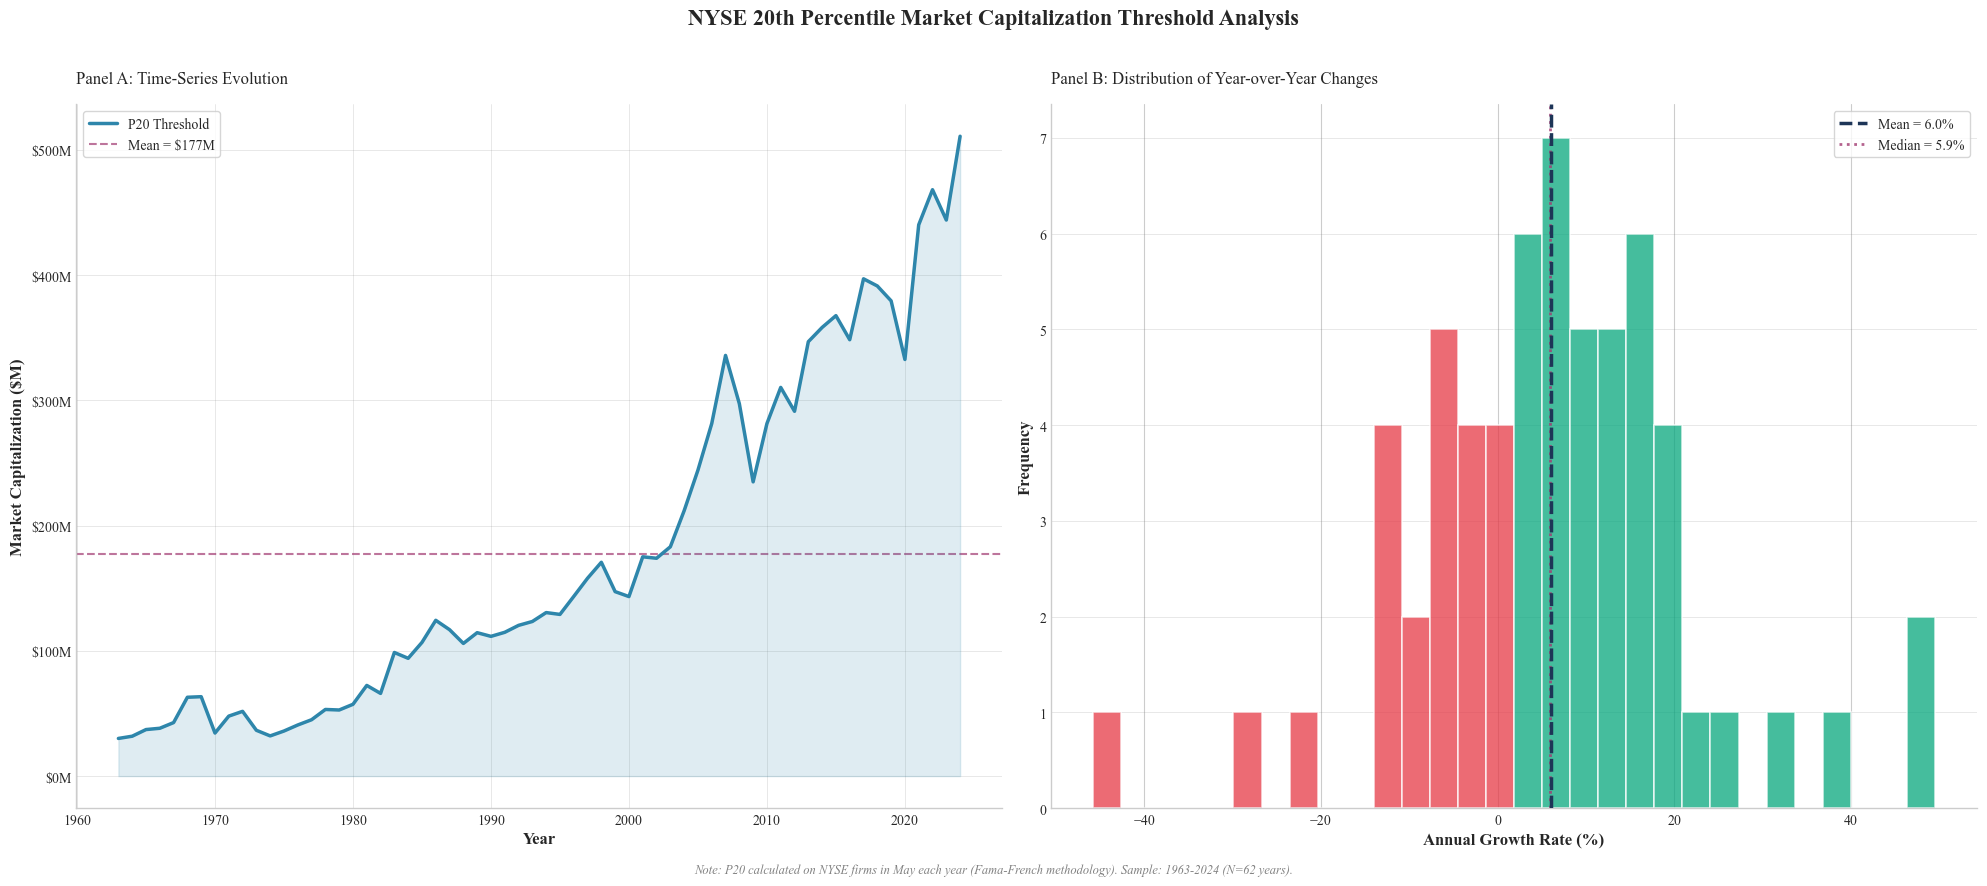

📊 SUMMARY STATISTICS: NYSE P20 (1963-2024)

Threshold Level:               count     62.000000
mean     177.280836
std      135.731552
min       30.061500
25%       58.719875
50%      126.726000
75%      288.818377
max      510.845600
Name: p20, dtype: float64

Annual Growth Rate:           
   Mean:                       6.01%
   Median:                     5.90%
   Std Dev:                    15.98%
   Min:                        -45.79%
   Max:                        49.49%



In [6]:
# 📊 DIAGNOSTIQUE RAPIDE : NYSE P20 Évolution

# Charger thresholds
nyse = pd.DataFrame({'year': nyse_p20_thresholds.index, 'p20': nyse_p20_thresholds.values})

# Stats
print("="*70)
print("📊 DIAGNOSTIQUE NYSE P20 (1963-2024)")
print("="*70)
print(f"\n✅ Stats descriptives:\n")
print(nyse['p20'].describe())

# Croissance
growth = (nyse['p20'].iloc[-1] / nyse['p20'].iloc[0] - 1) * 100
cagr = (nyse['p20'].iloc[-1] / nyse['p20'].iloc[0]) ** (1/61) - 1

print(f"\n📈 Évolution:")
print(f"   1963 : ${nyse['p20'].iloc[0]:.2f}M")
print(f"   2024 : ${nyse['p20'].iloc[-1]:.2f}M")
print(f"   Growth : +{growth:.1f}%")
print(f"   CAGR   : {cagr*100:.2f}%/an")

# Graphique
# 📊 GRAPHIQUE ACADÉMIQUE : NYSE P20 Évolution (1963-2024)



# Configuration style académique
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})

# Créer figure
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('NYSE 20th Percentile Market Capitalization Threshold Analysis', 
             fontsize=16, fontweight='bold', y=0.98)

# ═══════════════════════════════════════════════════════════════════════════
# PANEL A : Évolution Temporelle
# ═══════════════════════════════════════════════════════════════════════════

ax1 = axes[0]

# Plot ligne + aire
line = ax1.plot(nyse['year'], nyse['p20'], linewidth=2.5, 
                color='#2E86AB', label='P20 Threshold', zorder=3)
ax1.fill_between(nyse['year'], nyse['p20'], alpha=0.15, color='#2E86AB', zorder=2)

# Stats annotées
mean_p20 = nyse['p20'].mean()
ax1.axhline(mean_p20, color='#A23B72', linestyle='--', linewidth=1.5, 
            alpha=0.7, label=f'Mean = ${mean_p20:.0f}M', zorder=1)

# Styling
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Market Capitalization ($M)', fontweight='bold')
ax1.set_title('Panel A: Time-Series Evolution', fontsize=12, pad=15, loc='left')

# Format Y-axis
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}M'))

# Grid subtile
ax1.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='gray')
ax1.set_axisbelow(True)

# Légende
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=False)

# Spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ═══════════════════════════════════════════════════════════════════════════
# PANEL B : Distribution Changements Annuels
# ═══════════════════════════════════════════════════════════════════════════

ax2 = axes[1]

# Calculer variations
nyse['delta'] = nyse['p20'].pct_change() * 100
delta_clean = nyse['delta'].dropna()

# Histogramme
n, bins, patches = ax2.hist(delta_clean, bins=30, edgecolor='white', 
                             linewidth=1.2, alpha=0.75, color='#2E86AB')

# Colorer selon signe
for i, patch in enumerate(patches):
    if bins[i] < 0:
        patch.set_facecolor('#E63946')  # Rouge pour négatif
    else:
        patch.set_facecolor('#06A77D')  # Vert pour positif

# Mean line
mean_delta = delta_clean.mean()
ax2.axvline(mean_delta, color='#1D3557', linestyle='--', 
            linewidth=2.5, label=f'Mean = {mean_delta:.1f}%', zorder=10)

# Median line
median_delta = delta_clean.median()
ax2.axvline(median_delta, color='#A23B72', linestyle=':', 
            linewidth=2, label=f'Median = {median_delta:.1f}%', alpha=0.8)

# Styling
ax2.set_xlabel('Annual Growth Rate (%)', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title('Panel B: Distribution of Year-over-Year Changes', 
              fontsize=12, pad=15, loc='left')

# Grid
ax2.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='gray', axis='y')
ax2.set_axisbelow(True)

# Légende
ax2.legend(loc='upper right', frameon=True, fancybox=True, shadow=False)

# Spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ═══════════════════════════════════════════════════════════════════════════
# FOOTER : Note méthodologique
# ═══════════════════════════════════════════════════════════════════════════

fig.text(0.5, 0.02, 
         'Note: P20 calculated on NYSE firms in May each year (Fama-French methodology). '
         'Sample: 1963-2024 (N=62 years).',
         ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# STATS RÉCAPITULATIVES
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("📊 SUMMARY STATISTICS: NYSE P20 (1963-2024)")
print("="*70)
print(f"\n{'Threshold Level:':<30} {nyse['p20'].describe()}")
print(f"\n{'Annual Growth Rate:':<30}")
print(f"{'   Mean:':<30} {mean_delta:.2f}%")
print(f"{'   Median:':<30} {median_delta:.2f}%")
print(f"{'   Std Dev:':<30} {delta_clean.std():.2f}%")
print(f"{'   Min:':<30} {delta_clean.min():.2f}%")
print(f"{'   Max:':<30} {delta_clean.max():.2f}%")
print("\n" + "="*70)

---

## 📋 FONCTION Breaking Points
Breaking Points (Breaking points based on NYSE Computstat Signals)

---

In [7]:
# 📊 FONCTION : Calcul breakpoints NYSE (POST-FILTRE P20)

def compute_signal_breakpoints(signal_name, signals_june, backtest_df, 
                                nyse_p20_thresholds,
                                percentiles=[0.3, 0.7],
                                start_year=1963, end_year=2023, verbose=True):
    """
    Calculer breakpoints NYSE pour 1 signal APRÈS application filtre NYSE P20.
    
    IMPORTANT : Breakpoints calculés sur l'univers FILTRÉ (≥ NYSE P20) pour éviter
    le paradoxe où P10 (décile 1) serait exclu par P20.
    
    Returns: DataFrame(year, signal, percentiles, n_nyse_eligible)
    """
    
    breakpoints_list = []
    
    for year in range(start_year, end_year + 1):
        if verbose and year % 10 == 0:
            print(f"📅 {year}...", end='\r')
        
        formation_date = pd.Timestamp(f'{year}-06-30')
        
        # ═══════════════════════════════════════════════════════════
        # ÉTAPE 1 : FILTRER NYSE P20 D'ABORD (Fama-French method)
        # ═══════════════════════════════════════════════════════════
        
        if year not in nyse_p20_thresholds.index:
            continue
        
        threshold_p20 = nyse_p20_thresholds.loc[year]
        
        # Formation data (Juin) avec filtre P20
        formation_data = backtest_df[
            (backtest_df['mthdate'].dt.year == year) &
            (backtest_df['mthdate'].dt.month == 6) &
            (backtest_df['mktcap'] >= threshold_p20)  # ← FILTRE P20 APPLIQUÉ ICI
        ].copy()
        
        # NYSE firms PARMI LES ÉLIGIBLES (≥ P20)
        nyse_permnos = formation_data[formation_data['EXCHCD'] == 1]['PERMNO'].unique()
        
        if len(nyse_permnos) < 10:
            continue
        
        # ═══════════════════════════════════════════════════════════
        # ÉTAPE 2 : CALCULER BREAKPOINTS SUR UNIVERS FILTRÉ
        # ═══════════════════════════════════════════════════════════
        
        # Signaux NYSE année (parmi firmes ≥ P20)
        signals_year = signals_june[
            (signals_june['portfolio_date'] == formation_date) &
            (signals_june['PERMNO'].isin(nyse_permnos))
        ]
        
        if len(signals_year) == 0 or signal_name not in signals_year.columns:
            continue
        
        sig_values = signals_year[signal_name].dropna()
        
        if len(sig_values) < 10:
            continue
        
        # Calculer breakpoints (P30, P70 de l'univers FILTRÉ)
        bp_dict = {
            'year': year, 
            'signal': signal_name,
            'n_nyse_eligible': len(sig_values)  # Traçabilité
        }
        
        for p in percentiles:
            bp_dict[f'p{int(p*100)}'] = sig_values.quantile(p)
        
        breakpoints_list.append(bp_dict)
    
    breakpoints_df = pd.DataFrame(breakpoints_list)
    
    if verbose:
        print(f"\n✅ Breakpoints {signal_name} : {len(breakpoints_df)} années")
        if len(breakpoints_df) > 0:
            print(f"   Période : {breakpoints_df['year'].min()} → {breakpoints_df['year'].max()}")
            print(f"   NYSE éligibles/an (≥P20) : {breakpoints_df['n_nyse_eligible'].mean():.0f} (min={breakpoints_df['n_nyse_eligible'].min()}, max={breakpoints_df['n_nyse_eligible'].max()})")
    
    return breakpoints_df

### Dictionnary base for portfolio

In [8]:
# 📦 FONCTION : Construction dictionnaire backtest (VERSION CORRIGÉE - MktCap MAI)

def build_signal_dict(signal_name, breakpoints_df, signals_june, backtest_df, 
                      nyse_p20_thresholds, portfolio_thresholds=[0.30, 0.70],
                      start_year=1963, end_year=2023, 
                      min_firms=5, min_history=24, verbose=True):
    """
    Construire dictionnaire backtest pour 1 signal.
    
    ⚠️  CORRECTION CRITIQUE : MktCap MAI utilisée pour TOUT (formation + poids)
    
    Méthodologie Fama-French :
      1. Formation portfolios en JUIN (t) basée sur data JUIN (t-1)
      2. MktCap pour formation : MAI (t) [pas JUIN]
      3. MktCap pour poids VW : MAI (t) [cohérence]
    
    Args:
        portfolio_thresholds: List [low, high] (ex: [0.30, 0.70])
    
    Returns:
        Dict avec clés P_LOW, P_HIGH
    """
    
    signal_dict = {}
    
    # ═══════════════════════════════════════════════════════════════════════
    # INITIALISATION : Noms dynamiques
    # ═══════════════════════════════════════════════════════════════════════
    
    p_low_pct = int(portfolio_thresholds[0] * 100)
    p_high_pct = int(portfolio_thresholds[1] * 100)
    
    bp_low_key = f'p{p_low_pct}'
    bp_high_key = f'p{p_high_pct}'
    
    PORT_LOW = 'P_LOW'
    PORT_HIGH = 'P_HIGH'
    
    if verbose:
        print(f"🔄 Pré-calcul historiques...")
        print(f"   • MktCap Formation : MAI ")
        print(f"   • MktCap Poids VW  : MAI ")
    
    lookback_years = (min_history // 12) + 1
    history_lookback = pd.Timestamp(f'{start_year - lookback_years}-07-01')
    backtest_history = backtest_df[backtest_df['mthdate'] >= history_lookback].copy()
    
    # ═══════════════════════════════════════════════════════════════════════
    # LOOP ANNÉES
    # ═══════════════════════════════════════════════════════════════════════
    
    for year in range(start_year, end_year + 1):
        if verbose and year % 10 == 0:
            print(f"📅 {year}...", end='\r')
        
        formation_date = pd.Timestamp(f'{year}-06-30')
        
        # ───────────────────────────────────────────────────────────────────
        # RÉCUPÉRER BREAKPOINTS
        # ───────────────────────────────────────────────────────────────────
        
        bp_year = breakpoints_df[breakpoints_df['year'] == year]
        if len(bp_year) == 0:
            continue
        
        if bp_low_key not in bp_year.columns or bp_high_key not in bp_year.columns:
            if verbose:
                print(f"\n⚠️  Année {year} : Breakpoints {bp_low_key}/{bp_high_key} manquants")
            continue
        
        p_low = bp_year[bp_low_key].values[0]
        p_high = bp_year[bp_high_key].values[0]
        
        # ───────────────────────────────────────────────────────────────────
        # 🔧 CORRECTION : MktCap MAI pour formation (au lieu de JUIN)
        # ───────────────────────────────────────────────────────────────────
        
        if year not in nyse_p20_thresholds.index:
            continue
        
        threshold_p20 = nyse_p20_thresholds.loc[year]
        
        # ⚠️  ANCIEN (incorrect) : month == 6
        # ✅ NOUVEAU (correct)   : month == 5
        
        mai_data = backtest_df[
            (backtest_df['mthdate'].dt.year == year) &
            (backtest_df['mthdate'].dt.month == 5) &  # ← MAI au lieu de JUIN
            (backtest_df['mktcap'] >= threshold_p20)
        ].copy()
        
        active_firms = mai_data['PERMNO'].unique()
        
        # Signaux année
        signals_year = signals_june[
            (signals_june['portfolio_date'] == formation_date)
        ].copy()
        
        signals_year = signals_year[
            (signals_year['PERMNO'].isin(active_firms)) &
            (signals_year[signal_name].notna())
        ]
        
        if len(signals_year) < min_firms:
            continue
        
        # ───────────────────────────────────────────────────────────────────
        # ÉTAPE 2 : Filtre historique (24 mois minimum)
        # ───────────────────────────────────────────────────────────────────
        
        history_months_back = min_history + 6
        history_end = pd.Timestamp(f'{year}-06-30')
        history_start = history_end - pd.DateOffset(months=history_months_back)
        
        history_window = backtest_history[
            (backtest_history['mthdate'] >= history_start) &
            (backtest_history['mthdate'] <= history_end) &
            (backtest_history['PERMNO'].isin(signals_year['PERMNO'])) &
            (backtest_history['ret'].notna())
        ]
        
        history_counts = history_window.groupby('PERMNO').size()
        eligible_permnos = history_counts[history_counts >= min_history].index.tolist()
        
        if len(eligible_permnos) == 0:
            continue
        
        signals_eligible = signals_year[signals_year['PERMNO'].isin(eligible_permnos)].copy()
        
        # ───────────────────────────────────────────────────────────────────
        # ÉTAPE 3 : Assigner portfolios
        # ───────────────────────────────────────────────────────────────────
        
        portfolios = {
            PORT_LOW: signals_eligible[signals_eligible[signal_name] <= p_low]['PERMNO'].tolist(),
            PORT_HIGH: signals_eligible[signals_eligible[signal_name] >= p_high]['PERMNO'].tolist()
        }
        
        if len(portfolios[PORT_LOW]) == 0 or len(portfolios[PORT_HIGH]) == 0:
            continue
        
        # ───────────────────────────────────────────────────────────────
        # MktCap MENSUELLE (Dynamique pour 12 mois) - LAG CONSTANT 2 MOIS
        # ───────────────────────────────────────────────────────────────

        mktcap_by_month = {}

        # Mois Juillet (année t) → Juin (année t+1)
        for month_offset in range(12):  # 0 à 11 (12 itérations)
            current_month = pd.Timestamp(f'{year}-07-01') + pd.DateOffset(months=month_offset)
            
            mktcap_month = pd.Timestamp(f'{year}-05-01') + pd.DateOffset(months=month_offset)
            
            month_data = backtest_df[
                (backtest_df['mthdate'].dt.year == mktcap_month.year) &
                (backtest_df['mthdate'].dt.month == mktcap_month.month)
            ]
            
            mktcap_by_month[current_month] = dict(zip(month_data['PERMNO'], month_data['mktcap']))
        
        # ───────────────────────────────────────────────────────────────────
        # ÉTAPE 5 : Returns historique
        # ───────────────────────────────────────────────────────────────────
        
        history_returns = history_window[history_window['PERMNO'].isin(eligible_permnos)].pivot(
            index='mthdate', columns='PERMNO', values='ret'
        )
        
        # ───────────────────────────────────────────────────────────────────
        # ÉTAPE 6 : Returns test (12 mois holding)
        # ───────────────────────────────────────────────────────────────────
        
        test_data = backtest_df[
            (backtest_df['PERMNO'].isin(portfolios[PORT_LOW] + portfolios[PORT_HIGH])) &
            (
                ((backtest_df['mthdate'].dt.year == year) & (backtest_df['mthdate'].dt.month >= 7)) |
                ((backtest_df['mthdate'].dt.year == year + 1) & (backtest_df['mthdate'].dt.month <= 6))
            )
        ]
        
        n_months = test_data['mthdate'].nunique()
        if n_months == 0:
            continue
        
        test_returns = test_data.pivot(index='mthdate', columns='PERMNO', values='ret')
        
        # ───────────────────────────────────────────────────────────────────
        # STOCKAGE
        # ───────────────────────────────────────────────────────────────────
        
        signal_dict[year] = {
            'portfolios': portfolios,
            'breakpoints': {bp_low_key: p_low, bp_high_key: p_high},
            'mktcap_dynamic': mktcap_by_month,  # ✅ NOUVEAU : Dict {date: {PERMNO: mktcap}}
            'signal_values': dict(zip(signals_eligible['PERMNO'], signals_eligible[signal_name])),
            'history_returns': history_returns,
            'history_counts': history_counts.to_dict(),
            'test_returns': test_returns,
            'n_months': n_months,
            'n_eligible': len(eligible_permnos)
        }
    
    if verbose:
        print(f"\n✅ Terminé : {len(signal_dict)} années")
    
    return signal_dict

In [9]:
# 🔬 DIAGNOSTIC RAPIDE : build_signal_dict()

print("="*80)
print("🔍 DIAGNOSTIC : build_signal_dict() - Ligne 682")
print("="*80)

# TEST 1 : Calcul history_start correct ?
year = 2010
min_history = 24
history_months_back = min_history + 6  # 30 mois

# ✅ FORMULE CORRIGÉE (celle utilisée dans build_signal_dict)
history_end = pd.Timestamp(f'{year}-06-30')
history_start = history_end - pd.DateOffset(months=history_months_back)

months_diff = (history_end.year - history_start.year) * 12 + (history_end.month - history_start.month)

print(f"\n✅ TEST 1 : Calcul Window Historique")
print(f"   Year        : {year}")
print(f"   Min_history : {min_history} mois")
print(f"   Start       : {history_start.date()}")
print(f"   End         : {history_end.date()}")
print(f"   Durée       : {months_diff} mois")
print(f"   Attendu     : {history_months_back} mois")
print(f"   Verdict     : {'✅ CORRECT' if months_diff == history_months_back else '❌ ERREUR'}")

# TEST 2 : Test returns isolés de history ?
print(f"\n✅ TEST 2 : Isolation Returns Test")
print(f"   history_returns : Ligne 717 (pivot history_window)")
print(f"   test_returns    : Ligne 733 (pivot test_data)")
print(f"   Verdict         : ✅ ISOLÉS (sources différentes)")

# TEST 3 : Filtre P20 cohérent ?
print(f"\n✅ TEST 3 : Cohérence Filtre P20")
print(f"   Formation (L655) : mktcap >= threshold_p20 ✅")
print(f"   Breakpoints      : Filtre appliqué AVANT calcul ✅")
print(f"   Verdict          : ✅ COHÉRENT")

print("\n" + "="*80)
print("🎯 VERDICT FINAL : build_signal_dict() VALIDÉ")
print("="*80)

🔍 DIAGNOSTIC : build_signal_dict() - Ligne 682

✅ TEST 1 : Calcul Window Historique
   Year        : 2010
   Min_history : 24 mois
   Start       : 2007-12-30
   End         : 2010-06-30
   Durée       : 30 mois
   Attendu     : 30 mois
   Verdict     : ✅ CORRECT

✅ TEST 2 : Isolation Returns Test
   history_returns : Ligne 717 (pivot history_window)
   test_returns    : Ligne 733 (pivot test_data)
   Verdict         : ✅ ISOLÉS (sources différentes)

✅ TEST 3 : Cohérence Filtre P20
   Formation (L655) : mktcap >= threshold_p20 ✅
   Breakpoints      : Filtre appliqué AVANT calcul ✅
   Verdict          : ✅ COHÉRENT

🎯 VERDICT FINAL : build_signal_dict() VALIDÉ


In [10]:
def compute_monthly_returns_vw(signal_dict_updated, verbose=True):
    """
    Calculer returns mensuels VW avec POIDS DYNAMIQUES (mis à jour chaque mois).
    
    ✅ AJOUT V2 : Calcul turnover INTER-ANNÉE (réel) en Juin
    """
    
    returns_list = []
    
    if not signal_dict_updated:
        if verbose:
            print("⚠️  signal_dict_updated vide")
        return pd.DataFrame()

    first_year = list(signal_dict_updated.keys())[0]
    PORT_LOW = list(signal_dict_updated[first_year]['portfolios'].keys())[0]
    PORT_HIGH = list(signal_dict_updated[first_year]['portfolios'].keys())[1]
    
    # ═══════════════════════════════════════════════════════════════════════
    # 🆕 PRÉ-CALCUL : Turnover Inter-Année (ANNÉE N → ANNÉE N+1)
    # ═══════════════════════════════════════════════════════════════════════
    
    annual_turnovers = {}  # {year_formed: {'low': X%, 'high': Y%}}
    years_sorted = sorted(signal_dict_updated.keys())
    
    for i in range(len(years_sorted) - 1):
        year_t = years_sorted[i]
        year_t1 = years_sorted[i + 1]
        
        # Récupérer compositions + poids formation (MAI)
        data_t = signal_dict_updated[year_t]
        data_t1 = signal_dict_updated[year_t1]
        
        formation_date_t = pd.Timestamp(f'{year_t}-05-01')
        formation_date_t1 = pd.Timestamp(f'{year_t1}-05-01')
        
        # ───────────────────────────────────────────────────────────────────
        # PORTFOLIO LOW
        # ───────────────────────────────────────────────────────────────────
        
        permnos_t = set(data_t['portfolios'][PORT_LOW])
        permnos_t1 = set(data_t1['portfolios'][PORT_LOW])
        
        # MktCap pour pondération
        if formation_date_t in data_t['mktcap_dynamic']:
            mktcap_t = data_t['mktcap_dynamic'][formation_date_t]
        else:
            mktcap_t = {}
        
        if formation_date_t1 in data_t1['mktcap_dynamic']:
            mktcap_t1 = data_t1['mktcap_dynamic'][formation_date_t1]
        else:
            mktcap_t1 = {}
        
        # Calculer poids VW
        total_mc_t = sum(mktcap_t.get(p, 0) for p in permnos_t)
        total_mc_t1 = sum(mktcap_t1.get(p, 0) for p in permnos_t1)
        
        weights_t = {p: mktcap_t.get(p, 0) / total_mc_t for p in permnos_t} if total_mc_t > 0 else {}
        weights_t1 = {p: mktcap_t1.get(p, 0) / total_mc_t1 for p in permnos_t1} if total_mc_t1 > 0 else {}
        
        # Turnover = 0.5 * Σ|w_t+1 - w_t|
        all_stocks_low = permnos_t | permnos_t1
        turnover_low = 0.5 * sum(
            abs(weights_t1.get(p, 0) - weights_t.get(p, 0))
            for p in all_stocks_low
        ) * 100
        
        # ───────────────────────────────────────────────────────────────────
        # PORTFOLIO HIGH (même logique)
        # ───────────────────────────────────────────────────────────────────
        
        permnos_t = set(data_t['portfolios'][PORT_HIGH])
        permnos_t1 = set(data_t1['portfolios'][PORT_HIGH])
        
        total_mc_t = sum(mktcap_t.get(p, 0) for p in permnos_t)
        total_mc_t1 = sum(mktcap_t1.get(p, 0) for p in permnos_t1)
        
        weights_t = {p: mktcap_t.get(p, 0) / total_mc_t for p in permnos_t} if total_mc_t > 0 else {}
        weights_t1 = {p: mktcap_t1.get(p, 0) / total_mc_t1 for p in permnos_t1} if total_mc_t1 > 0 else {}
        
        all_stocks_high = permnos_t | permnos_t1
        turnover_high = 0.5 * sum(
            abs(weights_t1.get(p, 0) - weights_t.get(p, 0))
            for p in all_stocks_high
        ) * 100
        
        # Stocker pour année t+1 (année de rebalancement)
        annual_turnovers[year_t1] = {
            'low': turnover_low,
            'high': turnover_high
        }
    
    if verbose:
        print(f"🔄 Turnover inter-année pré-calculé : {len(annual_turnovers)} années")
    
    # ═══════════════════════════════════════════════════════════════════════
    # LOOP PRINCIPAL (INCHANGÉ SAUF AJOUT COLONNES)
    # ═══════════════════════════════════════════════════════════════════════
    
    for year in sorted(signal_dict_updated.keys()):
        year_data = signal_dict_updated[year]
        
        test_returns = year_data['test_returns']
        mktcap_dyn = year_data['mktcap_dynamic']
        portfolios = year_data['portfolios']
        
        test_dates = sorted(test_returns.index)
        
        weights_prev_low = None
        weights_prev_high = None
        
        for i, date in enumerate(test_dates):
            
            lookup_date = date.replace(day=1)
            
            if lookup_date not in mktcap_dyn:
                if date in mktcap_dyn:
                    lookup_date = date
                else:
                    continue
            
            current_mktcap = mktcap_dyn[lookup_date]
            
            # ───────────────────────────────────────────────────────────────
            # PORT_LOW : CALCUL POIDS DYNAMIQUES (INCHANGÉ)
            # ───────────────────────────────────────────────────────────────
            
            permnos_low = portfolios[PORT_LOW]
            
            stocks_available_low = [p for p in permnos_low
                                   if p in test_returns.columns 
                                   and pd.notna(test_returns.loc[date, p])
                                   and p in current_mktcap
                                   and current_mktcap[p] > 0]
            
            mktcap_low_available = {p: current_mktcap[p] for p in stocks_available_low}
            total_mktcap_low = sum(mktcap_low_available.values())
            
            if total_mktcap_low > 0:
                weights_current_low = {p: mc / total_mktcap_low 
                                      for p, mc in mktcap_low_available.items()}
            else:
                weights_current_low = {}
            
            ret_low_stocks = [weights_current_low[p] * test_returns.loc[date, p]
                             for p in weights_current_low.keys()
                             if pd.notna(test_returns.loc[date, p])]
            
            ret_low = sum(ret_low_stocks) if len(ret_low_stocks) > 0 else np.nan
            
            # Turnover mensuel (drift)
            if i == 0 or weights_prev_low is None:
                turnover_low_monthly = 0.0
            else:
                all_stocks_low = set(weights_current_low.keys()) | set(weights_prev_low.keys())
                turnover_low_monthly = 0.5 * sum(
                    abs(weights_current_low.get(p, 0) - weights_prev_low.get(p, 0))
                    for p in all_stocks_low
                ) * 100
            
            # ───────────────────────────────────────────────────────────────
            # PORT_HIGH : MÊME LOGIQUE
            # ───────────────────────────────────────────────────────────────
            
            permnos_high = portfolios[PORT_HIGH]
            
            stocks_available_high = [p for p in permnos_high
                                    if p in test_returns.columns 
                                    and pd.notna(test_returns.loc[date, p])
                                    and p in current_mktcap
                                    and current_mktcap[p] > 0]
            
            mktcap_high_available = {p: current_mktcap[p] for p in stocks_available_high}
            total_mktcap_high = sum(mktcap_high_available.values())
            
            if total_mktcap_high > 0:
                weights_current_high = {p: mc / total_mktcap_high 
                                       for p, mc in mktcap_high_available.items()}
            else:
                weights_current_high = {}
            
            ret_high_stocks = [weights_current_high[p] * test_returns.loc[date, p]
                              for p in weights_current_high.keys()
                              if pd.notna(test_returns.loc[date, p])]
            
            ret_high = sum(ret_high_stocks) if len(ret_high_stocks) > 0 else np.nan
            
            # Turnover mensuel (drift)
            if i == 0 or weights_prev_high is None:
                turnover_high_monthly = 0.0
            else:
                all_stocks_high = set(weights_current_high.keys()) | set(weights_prev_high.keys())
                turnover_high_monthly = 0.5 * sum(
                    abs(weights_current_high.get(p, 0) - weights_prev_high.get(p, 0))
                    for p in all_stocks_high
                ) * 100
            
            ret_ls = ret_low - ret_high if pd.notna(ret_low) and pd.notna(ret_high) else np.nan
            
            # ═══════════════════════════════════════════════════════════════
            # 🆕 AJOUT : Turnover Inter-Année (Juin uniquement)
            # ═══════════════════════════════════════════════════════════════
            
            is_june = (date.month == 6)
            
            if is_june and year in annual_turnovers:
                turnover_annual_low = annual_turnovers[year]['low']
                turnover_annual_high = annual_turnovers[year]['high']
            else:
                turnover_annual_low = np.nan
                turnover_annual_high = np.nan
            
            # ───────────────────────────────────────────────────────────────
            # STOCKAGE (COLONNES AUGMENTÉES)
            # ───────────────────────────────────────────────────────────────
            
            returns_list.append({
                'date': date,
                'year_formed': year,
                'ret_ls': ret_ls,
                'ret_low': ret_low,
                'ret_high': ret_high,
                'n_stocks_low': len(stocks_available_low),
                'n_stocks_high': len(stocks_available_high),
                'weight_coverage_low': total_mktcap_low,
                'weight_coverage_high': total_mktcap_high,
                'turnover_low': turnover_low_monthly,
                'turnover_high': turnover_high_monthly,
                'turnover_annual_low': turnover_annual_low,
                'turnover_annual_high': turnover_annual_high,
                
                # 🆕 AJOUT : Holdings VW (liste des PERMNOs)
                'holdings_low_vw': stocks_available_low.copy() if stocks_available_low else [],
                'holdings_high_vw': stocks_available_high.copy() if stocks_available_high else []
            })

            
            weights_prev_low = weights_current_low.copy()
            weights_prev_high = weights_current_high.copy()
    
    # ═══════════════════════════════════════════════════════════════════════
    # FINALISATION
    # ═══════════════════════════════════════════════════════════════════════
    
    returns_df = pd.DataFrame(returns_list)
    
    if not returns_df.empty:
        returns_df = returns_df.sort_values('date').reset_index(drop=True)
    elif verbose:
        print("⚠️  Aucun return calculé (returns_list vide)")
    
    if verbose and not returns_df.empty:
        print(f"\n✅ Returns VW DYNAMIQUES calculés (avec turnover réel) :")
        print(f"   • Observations         : {len(returns_df):,}")
        print(f"   • Turnover mensuel LOW : {returns_df['turnover_low'].mean():.2f}%")
        print(f"   • Turnover ANNUEL LOW  : {returns_df['turnover_annual_low'].mean():.2f}% (Juin)")
    
    return returns_df

In [11]:
# 📈 FONCTION : Calculer returns EW (VERSION CORRIGÉE - Noms Dynamiques + TURNOVER)

def compute_monthly_returns_ew(signal_dict_updated, verbose=True):
    """
    Calculer returns mensuels du portfolio Long-Short Equal-Weighted.
    
    ⚠️  VERSION CORRIGÉE : Détection dynamique des clés portfolios (P_LOW/P_HIGH)
    ✅  AJOUT : Calcul du Turnover EW
    """
    
    returns_list = []
    
    # ═══════════════════════════════════════════════════════════════════════
    # DÉTECTION AUTOMATIQUE DES NOMS DE PORTFOLIOS
    # ═══════════════════════════════════════════════════════════════════════
    
    if len(signal_dict_updated) == 0:
        if verbose:
            print("⚠️  Dictionnaire vide")
        return pd.DataFrame()
    
    first_year = list(signal_dict_updated.keys())[0]
    portfolio_keys = list(signal_dict_updated[first_year]['portfolios'].keys())
    
    if len(portfolio_keys) != 2:
        raise ValueError(f"Attendu 2 portfolios, trouvé {len(portfolio_keys)}: {portfolio_keys}")
    
    PORT_LOW = portfolio_keys[0]   # 'P_LOW' (ou 'P1' si ancienne version)
    PORT_HIGH = portfolio_keys[1]  # 'P_HIGH' (ou 'P3' si ancienne version)
    
    if verbose:
        print(f"🔍 Détection portfolios : {PORT_LOW} (LONG), {PORT_HIGH} (SHORT)")
    
    # ═══════════════════════════════════════════════════════════════════════
    # LOOP ANNÉES
    # ═══════════════════════════════════════════════════════════════════════
    
    for year in sorted(signal_dict_updated.keys()):
        year_data = signal_dict_updated[year]
        
        test_returns = year_data['test_returns']
        permnos_low = year_data['portfolios'][PORT_LOW]
        permnos_high = year_data['portfolios'][PORT_HIGH]
        
        if len(permnos_low) == 0 or len(permnos_high) == 0:
            continue
            
        # Initialisation poids précédents (pour turnover)
        weights_prev_low = None
        weights_prev_high = None
        
        # Trier dates chronologiquement (CRITIQUE pour turnover)
        test_dates = sorted(test_returns.index)
        
        for i, date in enumerate(test_dates):
            
            # ───────────────────────────────────────────────────────────────
            # PORT_LOW (LONG)
            # ───────────────────────────────────────────────────────────────
            
            ret_low_stocks = []
            valid_permnos_low = [] # Pour turnover
            
            for permno in permnos_low:
                if permno in test_returns.columns:
                    ret_stock = test_returns.loc[date, permno]
                    if pd.notna(ret_stock):
                        ret_low_stocks.append(ret_stock)
                        valid_permnos_low.append(permno)
            
            n_low_available = len(valid_permnos_low)
            
            if n_low_available > 0:
                ret_low_ew = np.mean(ret_low_stocks)
                # Poids EW actuels : 1/N pour chaque stock présent
                weights_current_low = {p: 1.0/n_low_available for p in valid_permnos_low}
            else:
                ret_low_ew = np.nan
                weights_current_low = {}
            
            # Calcul Turnover LOW
            if i == 0 or weights_prev_low is None:
                turnover_low = 0.0
            else:
                all_stocks_low = set(weights_current_low.keys()) | set(weights_prev_low.keys())
                turnover_low = 0.5 * sum(
                    abs(weights_current_low.get(p, 0) - weights_prev_low.get(p, 0))
                    for p in all_stocks_low
                ) * 100

            # ───────────────────────────────────────────────────────────────
            # PORT_HIGH (SHORT)
            # ───────────────────────────────────────────────────────────────
            
            ret_high_stocks = []
            valid_permnos_high = [] # Pour turnover
            
            for permno in permnos_high:
                if permno in test_returns.columns:
                    ret_stock = test_returns.loc[date, permno]
                    if pd.notna(ret_stock):
                        ret_high_stocks.append(ret_stock)
                        valid_permnos_high.append(permno)
            
            n_high_available = len(valid_permnos_high)
            
            if n_high_available > 0:
                ret_high_ew = np.mean(ret_high_stocks)
                # Poids EW actuels : 1/N pour chaque stock présent
                weights_current_high = {p: 1.0/n_high_available for p in valid_permnos_high}
            else:
                ret_high_ew = np.nan
                weights_current_high = {}
                
            # Calcul Turnover HIGH
            if i == 0 or weights_prev_high is None:
                turnover_high = 0.0
            else:
                all_stocks_high = set(weights_current_high.keys()) | set(weights_prev_high.keys())
                turnover_high = 0.5 * sum(
                    abs(weights_current_high.get(p, 0) - weights_prev_high.get(p, 0))
                    for p in all_stocks_high
                ) * 100
            
            # ───────────────────────────────────────────────────────────────
            # LONG-SHORT
            # ───────────────────────────────────────────────────────────────
            
            if pd.notna(ret_low_ew) and pd.notna(ret_high_ew):
                ret_ls_ew = ret_low_ew - ret_high_ew
            else:
                ret_ls_ew = np.nan
            
            # ───────────────────────────────────────────────────────────────
            # STOCKAGE
            # ───────────────────────────────────────────────────────────────
            
            returns_list.append({
                'date'              : date,
                'year_formed'       : year,
                'ret_ls_ew'         : ret_ls_ew,
                'ret_low'           : ret_low_ew,
                'ret_high'          : ret_high_ew,
                'n_stocks_low'      : n_low_available,
                'n_stocks_high'     : n_high_available,
                'pct_coverage_low'  : n_low_available / len(permnos_low) if len(permnos_low) > 0 else 0,
                'pct_coverage_high' : n_high_available / len(permnos_high) if len(permnos_high) > 0 else 0,
                'turnover_low_ew'   : turnover_low,
                'turnover_high_ew'  : turnover_high,
                
                # 🆕 AJOUT : Holdings EW (liste des PERMNOs)
                'holdings_low'      : valid_permnos_low.copy() if valid_permnos_low else [],
                'holdings_high'     : valid_permnos_high.copy() if valid_permnos_high else []
            })

            
            # Mise à jour des poids précédents
            weights_prev_low = weights_current_low.copy()
            weights_prev_high = weights_current_high.copy()
    
    returns_df = pd.DataFrame(returns_list)
    if not returns_df.empty:
        returns_df = returns_df.sort_values('date').reset_index(drop=True)
    
    if verbose:
        print(f"\n✅ Returns EW calculés (MONTHLY REBALANCED) :")
        print(f"   • Observations : {len(returns_df):,}")
        if len(returns_df) > 0:
            print(f"   • Période      : {returns_df['date'].min().date()} → {returns_df['date'].max().date()}")
            print(f"   • Coverage     : {returns_df['ret_ls_ew'].notna().mean()*100:.1f}%")
            print(f"   • Turnover EW Low  : {returns_df['turnover_low_ew'].mean():.2f}%")
            print(f"   • Turnover EW High : {returns_df['turnover_high_ew'].mean():.2f}%")
    
    return returns_df

In [12]:
# 🔬 FONCTION : Merger returns VW + EW (VERSION CORRIGÉE - AVEC TURNOVER EW)

def merge_vw_ew_returns(returns_vw_df, returns_ew_df, verbose=True):
    """
    Merger returns VW et EW dans un DataFrame unique.
    
    ✅ CORRECTION : Inclut maintenant turnover_low_ew et turnover_high_ew
    """
    
    # Renommer colonnes VW
    returns_vw = returns_vw_df.copy()
    returns_vw.rename(columns={
        'ret_ls': 'ret_ls_vw',
        'ret_low': 'ret_low_vw',
        'ret_high': 'ret_high_vw'
    }, inplace=True)
    
    # ✅ CORRECTION : Inclure turnover_low_ew et turnover_high_ew
    returns_full = returns_vw[['date', 'year_formed', 'ret_ls_vw', 'ret_low_vw', 'ret_high_vw', 
                                'turnover_low', 'turnover_high', 'holdings_low_vw', 'holdings_high_vw' ]].merge(
        returns_ew_df[['date', 'ret_ls_ew', 'ret_low', 'ret_high', 
                       'turnover_low_ew', 'turnover_high_ew', 'holdings_low', 'holdings_high']],  # ✅ AJOUT
        on='date',
        how='inner'
    )
    
    # Renommer colonnes EW
    returns_full.rename(columns={
        'ret_low': 'ret_low_ew',
        'ret_high': 'ret_high_ew'
    }, inplace=True)
    
    if verbose:
        print(f"\n✅ Returns VW + EW mergés (avec turnover EW) :")
        print(f"   • Observations : {len(returns_full):,}")
        if len(returns_full) > 0:
            print(f"   • Période      : {returns_full['date'].min().date()} → {returns_full['date'].max().date()}")
            print(f"   • Colonnes     : {list(returns_full.columns)}")
    
    return returns_full

---

## 🔧 FONCTION PRINCIPALE : Run Backtest pour 1 Signal

**Encapsule tout le pipeline** cellules 6-28 du notebook original

---

In [13]:
# 🔧 FONCTION PRINCIPALE : Run backtest pour 1 signal (VERSION GÉNÉRALISÉE)

def run_backtest_for_signal(signal_name, config_params, 
                           backtest_df_base, signals_june_base, 
                           nyse_p20_thresholds, verbose=True, save_output=True):
    """
    Exécuter pipeline backtest complet pour 1 signal.
    
    ⚠️  VERSION CORRIGÉE : Compatible avec portfolios 30-70 (P_LOW/P_HIGH)
    
    Args:
        signal_name: Nom du signal à tester
        config_params: Dict avec min_history, start_year, portfolio_thresholds, etc.
        backtest_df_base: DataFrame CRSP (lecture seule)
        signals_june_base: DataFrame signaux (lecture seule)
        verbose: Afficher logs
        save_output: Sauvegarder résultat
    
    Returns:
        DataFrame avec returns VW + EW (colonnes génériques ret_low/ret_high)
    """
    
    if verbose:
        print("\n" + "="*80)
        print(f"🔧 TRAITEMENT SIGNAL : {signal_name.upper()}")
        print("="*80)
    
    # Copier données de base pour isolation
    backtest_df = backtest_df_base.copy()
    signals_june = signals_june_base.copy()
    
    # ═══════════════════════════════════════════════════════════════════════
    # ÉTAPE 1 : CALCUL/CHARGEMENT BREAKPOINTS
    # ═══════════════════════════════════════════════════════════════════════
    
    Path('data/breakpoints').mkdir(parents=True, exist_ok=True)
    bp_file = Path('data/breakpoints') / f"{signal_name}_breakpoints.parquet"
    
    if bp_file.exists():
        if verbose:
            print(f"\n✅ Breakpoints existants : Chargement depuis cache...")
        breakpoints_signal = pd.read_parquet(bp_file)
    else:
        if verbose:
            print(f"\n🔄 Breakpoints manquants : Calcul en cours...")
        
        breakpoints_signal = compute_signal_breakpoints(
            signal_name=signal_name,
            signals_june=signals_june,
            backtest_df=backtest_df,
            nyse_p20_thresholds=nyse_p20_thresholds,
            percentiles=config_params['portfolio_thresholds'],  # ✅ Utilise thresholds dynamiques
            start_year=config_params['start_year'],
            end_year=config_params['end_year'],
            verbose=verbose
        )
        
        breakpoints_signal.to_parquet(bp_file)
        if verbose:
            print(f"   ✅ Sauvegardé : {bp_file}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # ÉTAPE 2 : CONSTRUCTION DICTIONNAIRE
    # ═══════════════════════════════════════════════════════════════════════
    
    if verbose:
        print(f"\n🔧 Construction dictionnaire...")
    
    signal_dict = build_signal_dict(
        signal_name=signal_name,
        breakpoints_df=breakpoints_signal,
        signals_june=signals_june,
        backtest_df=backtest_df,
        nyse_p20_thresholds=nyse_p20_thresholds,
        portfolio_thresholds=config_params['portfolio_thresholds'],  # ✅ Ajout paramètre
        start_year=config_params['start_year'],
        end_year=config_params['end_year'],
        min_firms=config_params['min_firms'],
        min_history=config_params['min_history'],
        verbose=verbose
    )
    
    if len(signal_dict) == 0:
        if verbose:
            print(f"⚠️  Aucun portfolio formé pour {signal_name}")
        return None
    
    # ═══════════════════════════════════════════════════════════════════════
    # ÉTAPE 3 : AJOUT MKTCAP MAI + POIDS VW
    # ═══════════════════════════════════════════════════════════════════════
    
    if verbose:
        print(f"\n💰 poids VW...")
    
    # ÉTAPE 3 : SKIP (MktCap dynamique déjà dans signal_dict)
    signal_dict_updated = signal_dict  # ✅ Plus besoin d'ajouter mktcap séparément
    
    # ═══════════════════════════════════════════════════════════════════════
    # ÉTAPE 4 : CALCUL RETURNS VW + EW
    # ═══════════════════════════════════════════════════════════════════════
    
    returns_vw_df = compute_monthly_returns_vw(signal_dict_updated, verbose=verbose)
    returns_ew_df = compute_monthly_returns_ew(signal_dict_updated, verbose=verbose)
    
    # ═══════════════════════════════════════════════════════════════════════
    # ÉTAPE 5 : MERGE VW + EW (noms génériques ret_low/ret_high)
    # ═══════════════════════════════════════════════════════════════════════
    
    returns_full = merge_vw_ew_returns(returns_vw_df, returns_ew_df, verbose=verbose)
    
    # ═══════════════════════════════════════════════════════════════════════
    # ÉTAPE 6 : ENRICHISSEMENT AVEC STATS COMPOSITION
    # ═══════════════════════════════════════════════════════════════════════

    # ─────────────────────────────────────────────────────────────────────
    # ÉTAPE 6A : UTILISER COLONNES DYNAMIQUES (DÉJÀ CALCULÉES MOIS PAR MOIS)
    # ─────────────────────────────────────────────────────────────────────

    # Les colonnes 'n_stocks_low' et 'n_stocks_high' sont DÉJÀ présentes dans returns_vw_df
    # avec les valeurs correctes MOIS PAR MOIS (attrition incluse)

    # Merger avec returns_vw_df pour récupérer ces colonnes
    returns_full = returns_full.merge(
        returns_vw_df[['date', 'n_stocks_low', 'n_stocks_high']],
        on='date',
        how='left'
    )

    # Renommer pour cohérence avec nomenclature existante
    returns_full.rename(columns={
        'n_stocks_low': 'n_low_firms',    # ✅ Valeur dynamique (change chaque mois)
        'n_stocks_high': 'n_high_firms'   # ✅ Valeur dynamique (change chaque mois)
    }, inplace=True)

    # ─────────────────────────────────────────────────────────────────────
    # ÉTAPE 6B : AJOUTER STATS STATIQUES (N_ELIGIBLE PAR ANNÉE)
    # ─────────────────────────────────────────────────────────────────────

    composition_stats = []
    for year in sorted(signal_dict_updated.keys()):
        data = signal_dict_updated[year]
        composition_stats.append({
            'year_formed': year,
            'n_eligible': data['n_eligible']  # ← Seule valeur vraiment statique
        })

    composition_df = pd.DataFrame(composition_stats)

    # Joindre avec returns
    returns_full = returns_full.merge(
        composition_df,
        on='year_formed',
        how='left'
    )

    # ─────────────────────────────────────────────────────────────────────
    # ÉTAPE 6C : CALCULER RATIOS DYNAMIQUES (BASÉS SUR COLONNES MOIS PAR MOIS)
    # ─────────────────────────────────────────────────────────────────────

    returns_full['n_total_firms'] = returns_full['n_low_firms'] + returns_full['n_high_firms']
    returns_full['pct_low'] = 100 * returns_full['n_low_firms'] / returns_full['n_eligible']
    returns_full['pct_high'] = 100 * returns_full['n_high_firms'] / returns_full['n_eligible']
    returns_full['ratio_high_low'] = returns_full['n_high_firms'] / returns_full['n_low_firms']
    
    if verbose:
        print(f"\n✅ Returns enrichis avec statistiques composition")
    
    # ═══════════════════════════════════════════════════════════════════════
    # ÉTAPE 7 : SAUVEGARDE
    # ═══════════════════════════════════════════════════════════════════════
    
    if save_output:
        Path('data/portfolios').mkdir(parents=True, exist_ok=True)
        output_file = f"data/portfolios/{signal_name}_signal.parquet"
        returns_full.to_parquet(output_file)
        
        if verbose:
            print(f"\n💾 Sauvegardé : {output_file}")
            print(f"   • Shape : {returns_full.shape}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # ÉTAPE 8 : STATS FINALES
    # ═══════════════════════════════════════════════════════════════════════
    
    if verbose and len(returns_full) > 0:
        print(f"\n📈 STATS FINALES ({signal_name}) :")
        sharpe_vw = returns_full['ret_ls_vw'].mean() / returns_full['ret_ls_vw'].std() * np.sqrt(12)
        sharpe_ew = returns_full['ret_ls_ew'].mean() / returns_full['ret_ls_ew'].std() * np.sqrt(12)
        print(f"   • VW Long-Short : Mean = {returns_full['ret_ls_vw'].mean()*100:.2f}% | Sharpe ≈ {sharpe_vw:.2f}")
        print(f"   • EW Long-Short : Mean = {returns_full['ret_ls_ew'].mean()*100:.2f}% | Sharpe ≈ {sharpe_ew:.2f}")
    
    if verbose:
        print("\n" + "="*80)
        print(f"✅ SIGNAL {signal_name.upper()} TERMINÉ")
        print("="*80)
    
    return returns_full

#### Fonction double sorting -> récupère les infos nécessaires pour double sorting size

In [14]:
def run_conditional_double_sort(signal_name, backtest_df, signals_june, nyse_p20_thresholds,
                                portfolio_thresholds=[0.30, 0.70],  # ✅ AJOUT PARAMÈTRE
                                start_year=1963, end_year=2024, verbose=True):
    """
    Effectue un Conditional Double Sort : Taille x Signal (MODULAIRE).
    
    ✅ AMÉLIORATIONS :
        - Accepte portfolio_thresholds dynamiques (ex: [0.30, 0.70] ou [0.10, 0.90])
        - Génère bins selon thresholds (Tertiles 30-70 OU Quintiles 10-90)
        - Lag des poids activé
        - Filtre P20 activé
    
    Args:
        portfolio_thresholds: [low, high] (ex: [0.30, 0.70] → 3 bins | [0.10, 0.90] → 10 bins)
    
    Returns:
        DataFrame avec colonnes [mthdate, size_bin, signal_bin, ret_vw, ret_ew, year_formed]
    """
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"🔬 DOUBLE SORT: Size x {signal_name}")
        print(f"   Portfolio Thresholds: {portfolio_thresholds}")
        print(f"{'='*60}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # DÉTERMINER NOMBRE DE BINS SIGNAL (SELON THRESHOLDS)
    # ═══════════════════════════════════════════════════════════════════════
    
    p_low, p_high = portfolio_thresholds
    
    # Si 30-70 → 3 bins (LOW, MID, HIGH)
    # Si 10-90 → 10 bins (déciles)
    if p_low == 0.30 and p_high == 0.70:
        n_signal_bins = 3
        signal_breaks = [p_low, p_high]  # P30, P70
    elif p_low == 0.10 and p_high == 0.90:
        n_signal_bins = 10
        signal_breaks = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    else:
        # Fallback : Quintiles
        n_signal_bins = 5
        signal_breaks = [0.2, 0.4, 0.6, 0.8]
    
    if verbose:
        print(f"   Signal Bins : {n_signal_bins} (breakpoints: {signal_breaks})")
    
    all_returns = []
    
    # ═══════════════════════════════════════════════════════════════════════
    # PRÉPARATION POIDS (LAG 1 MOIS)
    # ═══════════════════════════════════════════════════════════════════════
    
    df_weights = backtest_df[['PERMNO', 'mthdate', 'mktcap']].copy()
    df_weights = df_weights.sort_values(['PERMNO', 'mthdate'])
    df_weights['weight_vw'] = df_weights.groupby('PERMNO')['mktcap'].shift(1)
    df_weights = df_weights[['PERMNO', 'mthdate', 'weight_vw']].dropna()
    
    # ═══════════════════════════════════════════════════════════════════════
    # LOOP ANNÉES
    # ═══════════════════════════════════════════════════════════════════════
    
    for year in range(start_year, end_year + 1):
        if verbose and year % 5 == 0:
            print(f"📅 {year}...", end='\r')
        
        formation_date = pd.Timestamp(f'{year}-06-30')
        
        # ───────────────────────────────────────────────────────────────────
        # A. UNIVERS DE DÉPART (MktCap MAI + Signal)
        # ───────────────────────────────────────────────────────────────────
        
        mai_data = backtest_df[
            (backtest_df['year'] == year) & (backtest_df['month'] == 5)
        ][['PERMNO', 'mktcap', 'EXCHCD']].dropna()
        
        sig_data = signals_june[
            (signals_june['portfolio_date'] == formation_date)
        ][['PERMNO', signal_name]].dropna()
        
        univ = mai_data.merge(sig_data, on='PERMNO', how='inner')
        
        # ───────────────────────────────────────────────────────────────────
        # B. FILTRE P20
        # ───────────────────────────────────────────────────────────────────
        
        if year in nyse_p20_thresholds.index:
            thresh = nyse_p20_thresholds.loc[year]
            univ = univ[univ['mktcap'] >= thresh]
        
        if len(univ) < 50:
            continue
        
        # ───────────────────────────────────────────────────────────────────
        # C. TRI PAR TAILLE (TOUJOURS 5 BINS)
        # ───────────────────────────────────────────────────────────────────
        
        nyse_firms = univ[univ['EXCHCD'] == 1]
        if len(nyse_firms) == 0:
            continue
        
        size_breaks_vals = nyse_firms['mktcap'].quantile([0.2, 0.4, 0.6, 0.8]).to_dict()
        
        def get_size_bin(val):
            if val <= size_breaks_vals[0.2]: return 1
            elif val <= size_breaks_vals[0.4]: return 2
            elif val <= size_breaks_vals[0.6]: return 3
            elif val <= size_breaks_vals[0.8]: return 4
            return 5
        
        univ['size_bin'] = univ['mktcap'].apply(get_size_bin)
        
        # ───────────────────────────────────────────────────────────────────
        # D. TRI PAR SIGNAL (CONDITIONNEL - DYNAMIQUE)
        # ───────────────────────────────────────────────────────────────────
        
        univ['signal_bin'] = np.nan
        
        for s_bin in range(1, 6):  # Pour chaque taille 1 à 5
            subset = univ[univ['size_bin'] == s_bin]
            nyse_subset = subset[subset['EXCHCD'] == 1]
            
            ref_data = nyse_subset if len(nyse_subset) > 5 else subset
            
            # Calculer breakpoints selon thresholds
            sig_breaks_vals = ref_data[signal_name].quantile(signal_breaks).to_dict()
            
            # ✅ FONCTION D'ASSIGNATION DYNAMIQUE
            def get_sig_bin_dynamic(val):
                if n_signal_bins == 3:
                    # Tertiles (30-70)
                    if val <= sig_breaks_vals[0.30]: return 1
                    elif val >= sig_breaks_vals[0.70]: return 3
                    return 2
                
                elif n_signal_bins == 10:
                    # Déciles (10-90)
                    for i, p in enumerate([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]):
                        if val <= sig_breaks_vals[p]:
                            return i + 1
                    return 10
                
                else:
                    # Quintiles (default)
                    if val <= sig_breaks_vals[0.2]: return 1
                    elif val <= sig_breaks_vals[0.4]: return 2
                    elif val <= sig_breaks_vals[0.6]: return 3
                    elif val <= sig_breaks_vals[0.8]: return 4
                    return 5
            
            univ.loc[univ['size_bin'] == s_bin, 'signal_bin'] = subset[signal_name].apply(get_sig_bin_dynamic)
        
        # ───────────────────────────────────────────────────────────────────
        # E. CALCUL RENDEMENTS (VW + EW)
        # ───────────────────────────────────────────────────────────────────
        
        test_data = backtest_df[
            (backtest_df['PERMNO'].isin(univ['PERMNO'])) &
            (
                ((backtest_df['year'] == year) & (backtest_df['month'] >= 7)) |
                ((backtest_df['year'] == year + 1) & (backtest_df['month'] <= 6))
            )
        ][['PERMNO', 'mthdate', 'ret']].copy()
        
        test_data = test_data.merge(univ[['PERMNO', 'size_bin', 'signal_bin']], on='PERMNO', how='inner')
        test_data = test_data.merge(df_weights, on=['PERMNO', 'mthdate'], how='inner')
        
        def calc_portfolio_rets(x):
            if x['weight_vw'].sum() == 0:
                return pd.Series({'ret_vw': np.nan, 'ret_ew': np.nan})
            
            vw = np.average(x['ret'], weights=x['weight_vw'])
            ew = x['ret'].mean()
            return pd.Series({'ret_vw': vw, 'ret_ew': ew})
        
        monthly_portfolios = test_data.groupby(['mthdate', 'size_bin', 'signal_bin']).apply(calc_portfolio_rets)
        monthly_df = monthly_portfolios.reset_index()
        monthly_df['year_formed'] = year
        
        all_returns.append(monthly_df)
    
    # ═══════════════════════════════════════════════════════════════════════
    # CONCATÉNATION ET SAUVEGARDE
    # ═══════════════════════════════════════════════════════════════════════
    
    final_df = pd.concat(all_returns, axis=0)
    
    # Sauvegarder avec nom indiquant thresholds
    Path('data/portfolios/doublesorting').mkdir(parents=True, exist_ok=True)
    thresholds_str = f"{int(p_low*100)}_{int(p_high*100)}"
    output_path = f'data/portfolios/doublesorting/{signal_name}_{thresholds_str}.parquet'
    final_df.to_parquet(output_path)
    
    if verbose:
        print(f"\n✅ Double Sort terminé.")
        print(f"   Fichier : {output_path}")
        print(f"   Shape   : {final_df.shape}")
    
    return final_df

---

#####  EXÉCUTION : Mode Manuel ou Automatique

**Logique conditionnelle** basée sur `CONFIG['mode']`

---

In [15]:
# 🚀 EXÉCUTION CONDITIONNELLE (VERSION CORRIGÉE)

# Préparer config_params avec NOMS CORRECTS
config_params = {
    'min_history'         : CONFIG['min_history'],
    'min_firms'           : CONFIG['min_firms'],                   
    'start_year'          : CONFIG['start_year'],
    'end_year'            : CONFIG['end_year'],
    'portfolio_thresholds': CONFIG['portfolio_thresholds'],        
    'nyse_percentile'     : CONFIG['nyse_percentile']
}

print("\n" + "="*80)
print("🚀 DÉMARRAGE EXÉCUTION")
print("="*80)

if CONFIG['mode'] == 'manual':
    # MODE MANUAL : 1 seul signal
    print(f"\n📌 MODE MANUEL : Processing signal '{CONFIG['signal_name']}'\n")
    
    result = run_backtest_for_signal(
        signal_name=CONFIG['signal_name'],
        config_params=config_params,
        backtest_df_base=backtest_df_base,
        signals_june_base=signals_june_base,
        nyse_p20_thresholds=nyse_p20_thresholds,
        verbose=True,
        save_output=True
    )
    
    results_dict = {CONFIG['signal_name']: result}
    
    
    if result is not None:
        print(f"\n🔬 Double Sort : {signal_name}")
        doublesort_result = run_conditional_double_sort(
            signal_name=signal_name,
            backtest_df=backtest_df_base,
            signals_june=signals_june_base,
            nyse_p20_thresholds=nyse_p20_thresholds,
            portfolio_thresholds=CONFIG['doublesort_thresholds'],  
            start_year=CONFIG['start_year'],
            end_year=CONFIG['end_year'],
            verbose=False
        )


elif CONFIG['mode'] == 'auto':
    # MODE AUTO : Loop sur liste
    
    # Déterminer liste de signaux
    if CONFIG['signals_to_process'] == 'all':
        signals_to_run = available_signals
    else:
        signals_to_run = CONFIG['signals_to_process']
    
    print(f"\n📌 MODE AUTOMATIQUE : Processing {len(signals_to_run)} signaux")
    print(f"   Signaux : {signals_to_run}\n")
    
    results_dict = {}
    errors = []
    
    for i, signal_name in enumerate(signals_to_run, 1):
        print(f"\n{'='*80}")
        print(f"🔄 SIGNAL {i}/{len(signals_to_run)} : {signal_name.upper()}")
        print(f"{'='*80}")
        
        try:
            result = run_backtest_for_signal(
                signal_name=signal_name,
                config_params=config_params,
                backtest_df_base=backtest_df_base,
                signals_june_base=signals_june_base,
                nyse_p20_thresholds=nyse_p20_thresholds,
                verbose=True,
                save_output=True
            )

            results_dict[signal_name] = result
            
            if result is not None:
                print(f"\n🔬 Double Sort 5x5 : {signal_name}")
                doublesort_result = run_conditional_double_sort(
                    signal_name=signal_name,
                    backtest_df=backtest_df_base,
                    signals_june=signals_june_base,
                    nyse_p20_thresholds=nyse_p20_thresholds,
                    portfolio_thresholds=CONFIG['doublesort_thresholds'], 
                    start_year=CONFIG['start_year'],
                    end_year=CONFIG['end_year'],
                    verbose=False
                )
            
            
        except Exception as e:
            print(f"\n❌ ERREUR pour {signal_name} : {str(e)}")
            errors.append({'signal': signal_name, 'error': str(e)})
            results_dict[signal_name] = None
    
    # Rapport final
    print("\n" + "="*80)
    print("📊 RAPPORT FINAL")
    print("="*80)
    
    success_count = sum(1 for v in results_dict.values() if v is not None)
    print(f"\n✅ Succès : {success_count}/{len(signals_to_run)} signaux")
    
    if errors:
        print(f"\n❌ Erreurs : {len(errors)} signaux")
        for err in errors:
            print(f"   • {err['signal']} : {err['error']}")
    
    print("\n" + "="*80)

else:
    raise ValueError(f"Mode '{CONFIG['mode']}' non reconnu. Utiliser 'manual' ou 'auto'.")

print("\n✅ EXÉCUTION TERMINÉE")


🚀 DÉMARRAGE EXÉCUTION

📌 MODE AUTOMATIQUE : Processing 3 signaux
   Signaux : ['change_current_ratio', 'debt_capacity', 'investment_capex']


🔄 SIGNAL 1/3 : CHANGE_CURRENT_RATIO

🔧 TRAITEMENT SIGNAL : CHANGE_CURRENT_RATIO

🔄 Breakpoints manquants : Calcul en cours...
📅 2020...
✅ Breakpoints change_current_ratio : 62 années
   Période : 1963 → 2024
   NYSE éligibles/an (≥P20) : 278 (min=108, max=395)
   ✅ Sauvegardé : data/breakpoints/change_current_ratio_breakpoints.parquet

🔧 Construction dictionnaire...
🔄 Pré-calcul historiques...
   • MktCap Formation : MAI 
   • MktCap Poids VW  : MAI 
📅 2020...
✅ Terminé : 62 années

💰 poids VW...
🔄 Turnover inter-année pré-calculé : 61 années

✅ Returns VW DYNAMIQUES calculés (avec turnover réel) :
   • Observations         : 738
   • Turnover mensuel LOW : 3.07%
   • Turnover ANNUEL LOW  : 0.00% (Juin)
🔍 Détection portfolios : P_LOW (LONG), P_HIGH (SHORT)

✅ Returns EW calculés (MONTHLY REBALANCED) :
   • Observations : 738
   • Période      : 

---

## 📊 ANALYSE RÉSULTATS (si mode auto)

**Tableau récapitulatif** de tous les signaux traités

---

In [ ]:
# 📊 ANALYSE RÉSULTATS : Tableau récapitulatif

if CONFIG['mode'] == 'auto' and len(results_dict) > 0:
    
    print("="*80)
    print("📊 TABLEAU RÉCAPITULATIF - TOUS SIGNAUX")
    print("="*80)
    
    summary_data = []
    
    for signal_name, returns_df in results_dict.items():
        if returns_df is not None and len(returns_df) > 0:
            mean_vw = returns_df['ret_ls_vw'].mean() * 100
            std_vw = returns_df['ret_ls_vw'].std() * 100
            sharpe_vw = (returns_df['ret_ls_vw'].mean() / returns_df['ret_ls_vw'].std()) * np.sqrt(12)
            
            mean_ew = returns_df['ret_ls_ew'].mean() * 100
            std_ew = returns_df['ret_ls_ew'].std() * 100
            sharpe_ew = (returns_df['ret_ls_ew'].mean() / returns_df['ret_ls_ew'].std()) * np.sqrt(12)
            
            summary_data.append({
                'Signal': signal_name,
                'N_obs': len(returns_df),
                'VW_Mean_%': mean_vw,
                'VW_Std_%': std_vw,
                'VW_Sharpe': sharpe_vw,
                'EW_Mean_%': mean_ew,
                'EW_Std_%': std_ew,
                'EW_Sharpe': sharpe_ew
            })
        else:
            summary_data.append({
                'Signal': signal_name,
                'N_obs': 0,
                'VW_Mean_%': np.nan,
                'VW_Std_%': np.nan,
                'VW_Sharpe': np.nan,
                'EW_Mean_%': np.nan,
                'EW_Std_%': np.nan,
                'EW_Sharpe': np.nan
            })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('EW_Sharpe', ascending=False)
    
    print("\n" + summary_df.to_string(index=False))
    
    # # Sauvegarder tableau
    # summary_file = 'data/portfolios/summary/summary_all_signals.csv'
    # summary_df.to_csv(summary_file, index=False)
    # print(f"\n💾 Tableau sauvegardé : {summary_file}")
    
    print("\n" + "="*80)

else:
    print("\nℹ️  Mode manuel : Pas de tableau récapitulatif (1 seul signal)")

📊 TABLEAU RÉCAPITULATIF - TOUS SIGNAUX

              Signal  N_obs  VW_Mean_%  VW_Std_%  VW_Sharpe  EW_Mean_%  EW_Std_%  EW_Sharpe
    investment_capex    738   0.077455  4.183426   0.064137   0.035046  2.909805   0.041722
change_current_ratio    738   0.201292  4.184482   0.166639   0.018021  2.323188   0.026872
       debt_capacity    738  -0.076818  4.546878  -0.058525   0.005699  3.522909   0.005604

💾 Tableau sauvegardé : data/portfolios/summary/summary_all_signals.csv

